In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Position_Salaries.csv")

In [3]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [5]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [6]:
df.isnull().sum()

,0
Position,0
Level,0
Salary,0


In [7]:
X = df.iloc[:, 1:2].values
y = df.iloc[:, 2].values

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_poly, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test_poly)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 70635.24590164085
Mean Squared Error (MSE): 6263853282.860292
R² Score: 0.8762695647830065


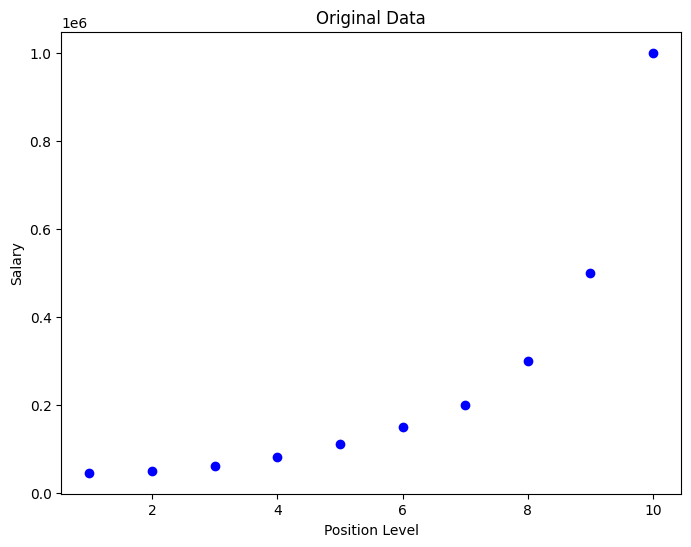

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color="blue")

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Original Data")

plt.show()

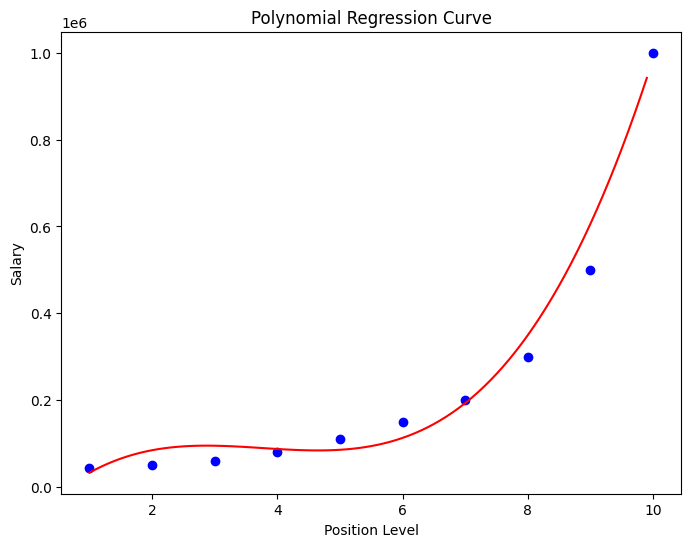

In [16]:
X_grid = np.arange(X.min(), X.max(), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.figure(figsize=(8,6))

plt.scatter(X, y, color="blue")

plt.plot(
    X_grid,
    model.predict(poly.transform(X_grid)),
    color="red"
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression Curve")

plt.show()

## Observations

1. The Polynomial Regression model captures the non-linear relationship between position level and salary more accurately than a simple linear model.
2. The polynomial regression curve closely follows the actual salary values, resulting in improved prediction performance.
3. The model achieved a good R² score, indicating that it explains most of the variation in employee salaries.

## Conclusion

This project successfully developed a Polynomial Regression model to predict employee salaries based on position level. The input feature was transformed using Polynomial Features of degree 3 to capture the non-linear relationship between position level and salary. The model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score, demonstrating good predictive performance. Unlike Linear Regression, which assumes a straight-line relationship, Polynomial Regression can model curved relationships and therefore provides better predictions for this dataset. One major advantage of Polynomial Regression is its ability to accurately fit non-linear patterns present in real-world data.